# AI in Cybersecurity (ICT4416) — Internal Assessment 4
## Network Intrusion Detection System (NIDS) using Machine Learning
**Dataset:** UNSW-NB15 (subset — 40,000 training / 10,000 testing samples)  
**Task:** Binary Classification — Normal (0) vs Attack (1)

## 0. Imports & Setup

In [33]:
# Import core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing and feature selection
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

# Handle imbalance
from imblearn.over_sampling import SMOTE

# ML models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    fbeta_score, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, auc, roc_auc_score,
    classification_report
)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

print('Libraries loaded.')

Libraries loaded.


---
## 1. Load Dataset

In [34]:
train_df = pd.read_csv('data/UNSW_NB15_train_40k.csv')
test_df  = pd.read_csv('data/UNSW_NB15_test_10k.csv')

print(f'Training set : {train_df.shape[0]:,} rows × {train_df.shape[1]} columns')
print(f'Testing  set : {test_df.shape[0]:,} rows × {test_df.shape[1]} columns')
train_df.head()

Training set : 40,000 rows × 16 columns
Testing  set : 10,000 rows × 16 columns


,proto,state,service,dur,sbytes,dbytes,spkts,dpkts,sload,dload,sttl,dttl,smean,dmean,sinpkt,label
0,pri-enc,INT,-,0.000009,200,0,2,0,8.888889e+07,0.000000e+00,254,0,100,0,0.009000,1
1,tcp,FIN,-,0.049860,3926,57474,66,68,6.204572e+05,9.086081e+06,31,29,59,845,0.761846,0
2,tcp,FIN,-,0.998910,608,646,10,10,4.388784e+03,4.661081e+03,254,252,61,65,110.990000,1
3,tcp,FIN,smtp,0.595864,37492,3172,52,38,4.936831e+05,4.147255e+04,31,29,721,83,11.676843,0
4,udp,INT,-,0.000009,104,0,2,0,4.622222e+07,0.000000e+00,254,0,52,0,0.009000,0


## 1. Exploratory Data Analysis (EDA)

### 1.1 Dataset Structure & Basic Info

In [35]:
print('Data Types:')
print(train_df.dtypes)
print('\nStatistical Summary:')
train_df.describe(include='all')

Data Types:
proto       object
state       object
service     object
dur        float64
sbytes       int64
dbytes       int64
spkts        int64
dpkts        int64
sload      float64
dload      float64
sttl         int64
dttl         int64
smean        int64
dmean        int64
sinpkt     float64
label        int64
dtype: object

Statistical Summary:


,proto,state,service,dur,sbytes,dbytes,spkts,dpkts,sload,dload,sttl,dttl,smean,dmean,sinpkt,label
count,40000,40000,40000,40000.000000,4.000000e+04,4.000000e+04,40000.000000,40000.000000,4.000000e+04,4.000000e+04,40000.00000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000
unique,133,7,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,tcp,FIN,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,23683,22666,24068,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,1.181550,6.409099e+03,2.471327e+04,26.478525,30.275575,4.572907e+07,1.471366e+06,121.09915,70.684150,140.207025,198.178100,2068.309464,0.300000
std,NaN,NaN,NaN,5.715719,1.252525e+05,1.708381e+05,106.980146,129.778977,1.750041e+08,3.451494e+06,108.93431,97.926862,198.910097,305.898615,10659.913291,0.458263
min,NaN,NaN,NaN,0.000000,4.600000e+01,0.000000e+00,1.000000,0.000000,0.000000e+00,0.000000e+00,0.00000,0.000000,28.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,NaN,0.000010,1.460000e+02,0.000000e+00,2.000000,0.000000,1.244276e+04,0.000000e+00,31.00000,0.000000,57.000000,0.000000,0.009000,0.000000
50%,NaN,NaN,NaN,0.026797,8.100000e+02,3.200000e+02,10.000000,6.000000,5.179283e+05,1.507469e+04,31.00000,29.000000,73.000000,78.000000,1.165287,0.000000
75%,NaN,NaN,NaN,0.647432,2.558000e+03,3.380000e+03,22.000000,22.000000,4.667234e+06,6.872587e+05,254.00000,29.000000,117.000000,136.000000,55.519361,1.000000


In [36]:
print('Missing Values:')
print(train_df.isnull().sum())
print('\nNo missing values — dataset is complete.')

Missing Values:
proto      0
state      0
service    0
dur        0
sbytes     0
dbytes     0
spkts      0
dpkts      0
sload      0
dload      0
sttl       0
dttl       0
smean      0
dmean      0
sinpkt     0
label      0
dtype: int64

No missing values — dataset is complete.


### 1.2 Class Distribution

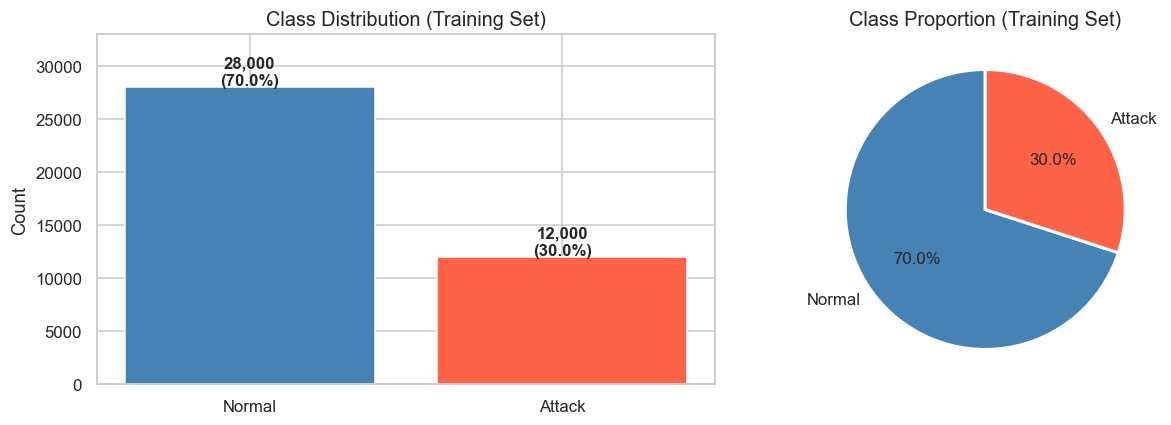


Interpretation: The dataset is imbalanced — 70% Normal vs 30% Attack.
This imbalance must be addressed during preprocessing to prevent model bias.


In [37]:
label_map = {0: 'Normal', 1: 'Attack'}
counts = train_df['label'].map(label_map).value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(counts.index, counts.values, color=['steelblue', 'tomato'], edgecolor='white')
for i, (label, val) in enumerate(zip(counts.index, counts.values)):
    axes[0].text(i, val + 200, f'{val:,}\n({val/len(train_df)*100:.1f}%)',
                 ha='center', fontweight='bold')
axes[0].set_title('Class Distribution (Training Set)', fontsize=13)
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, 33000)

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['steelblue', 'tomato'], startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Class Proportion (Training Set)', fontsize=13)

plt.tight_layout()
plt.savefig('outputs/class_distribution.png', bbox_inches='tight')
plt.show()

print('\nInterpretation: The dataset is imbalanced — 70% Normal vs 30% Attack.')
print('This imbalance must be addressed during preprocessing to prevent model bias.')

### 1.3 Categorical Feature Analysis

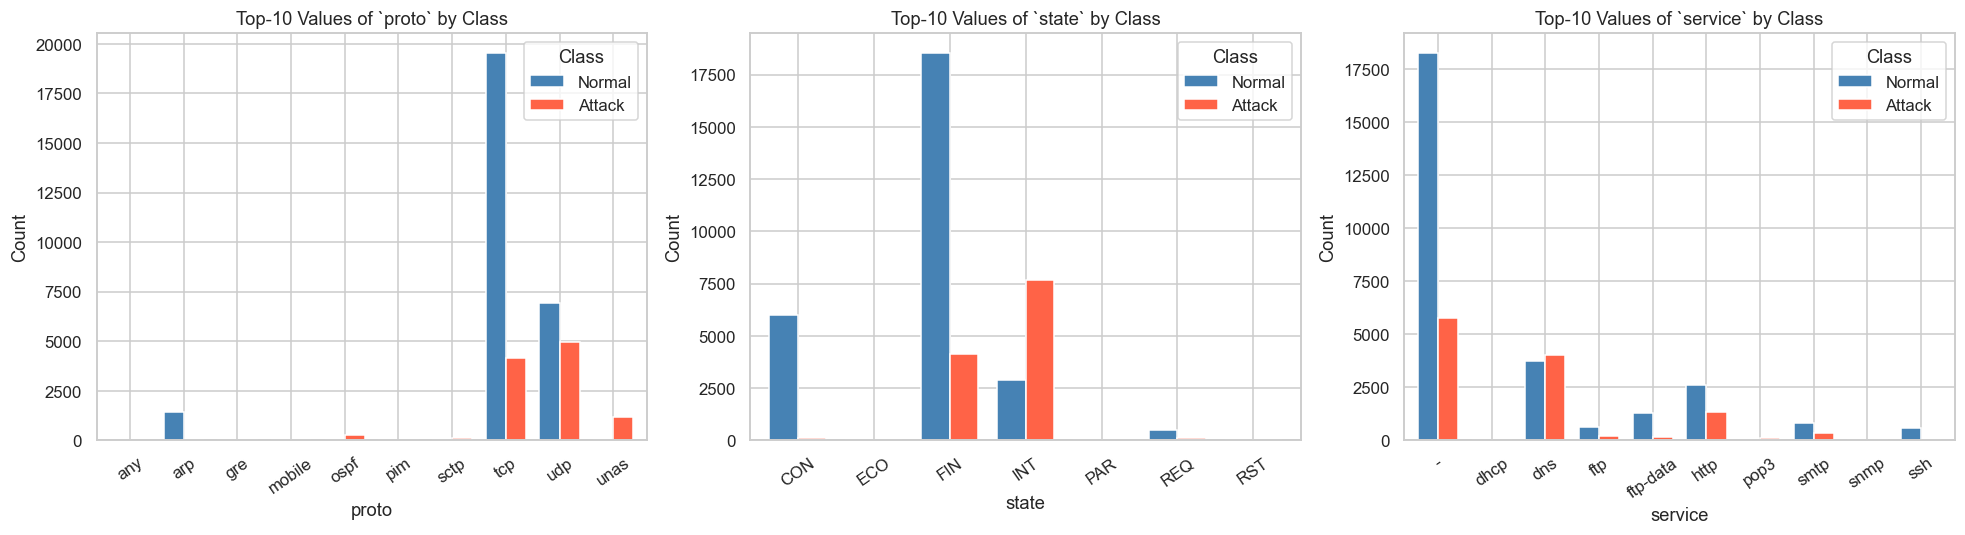


Interpretation:
  proto  : TCP & UDP dominate; some protocols (arp, unas) skew toward attacks.
  state  : FIN is most common for normal; INT state has high attack ratio.
  service: "-" (no service) is most frequent; DNS and HTTP are mostly normal.


In [38]:
cat_features = ['proto', 'state', 'service']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feat in zip(axes, cat_features):
    # Show top-10 categories coloured by label ratio
    top_vals = train_df[feat].value_counts().head(10).index
    sub = train_df[train_df[feat].isin(top_vals)]
    ct = sub.groupby([feat, 'label']).size().unstack(fill_value=0)
    ct.index = ct.index.astype(str)
    ct.columns = ['Normal', 'Attack']
    ct.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'],
            edgecolor='white', width=0.75)
    ax.set_title(f'Top-10 Values of `{feat}` by Class', fontsize=12)
    ax.set_xlabel(feat)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=35)
    ax.legend(title='Class')

plt.tight_layout()
plt.savefig('outputs/categorical_features.png', bbox_inches='tight')
plt.show()

print('\nInterpretation:')
print('  proto  : TCP & UDP dominate; some protocols (arp, unas) skew toward attacks.')
print('  state  : FIN is most common for normal; INT state has high attack ratio.')
print('  service: "-" (no service) is most frequent; DNS and HTTP are mostly normal.')

### 1.4 Numerical Feature Distributions

In [ ]:
num_features = ['dur', 'sbytes', 'dbytes', 'spkts', 'dpkts',
                'sload', 'dload', 'sttl', 'dttl', 'smean', 'dmean', 'sinpkt']

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

for ax, feat in zip(axes, num_features):
    for lbl, color, name in [(0, 'steelblue', 'Normal'), (1, 'tomato', 'Attack')]:
        data = train_df[train_df['label'] == lbl][feat]
        ax.hist(np.log1p(data), bins=40, alpha=0.6, color=color, label=name, density=True)
    ax.set_title(f'{feat} (log scale)', fontsize=10)
    ax.set_xlabel('log1p(value)')
    ax.legend(fontsize=8)

plt.suptitle('Numerical Feature Distributions by Class (log-transformed)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('outputs/num_distributions.png', bbox_inches='tight')
plt.show()

# Skewness report
print('\nSkewness of Numerical Features:')
skew_vals = train_df[num_features].skew().sort_values(ascending=False)
print(skew_vals.to_string())
print('\nInterpretation: All numerical features are highly right-skewed,'
      ' indicating presence of extreme outliers. Log-transformation is appropriate.')

### 1.5 Correlation Heatmap

In [ ]:
fig, ax = plt.subplots(figsize=(13, 10))
corr = train_df[num_features + ['label']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Correlation Heatmap (Numerical Features + Label)', fontsize=13)
plt.tight_layout()
plt.savefig('outputs/correlation_heatmap.png', bbox_inches='tight')
plt.show()

print('\nKey Observations:')
print('  - sbytes & smean are moderately correlated with each other.')
print('  - sload correlates with sbytes (load is derived from bytes).')
print('  - sttl & dttl have distinct distributions for Normal vs Attack — useful features.')
print('  - sinpkt (inter-packet time) shows high variance between classes.')

### 1.6 Feature vs Label — Boxplots

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

for ax, feat in zip(axes, num_features):
    plot_df = train_df[['label', feat]].copy()
    plot_df['label'] = plot_df['label'].map({0: 'Normal', 1: 'Attack'})
    plot_df[feat] = np.log1p(plot_df[feat])
    sns.boxplot(data=plot_df, x='label', y=feat, palette={'Normal': 'steelblue', 'Attack': 'tomato'}, ax=ax)
    ax.set_title(f'log1p({feat})', fontsize=10)
    ax.set_xlabel('')

plt.suptitle('Feature Distribution per Class (Boxplots, log-transformed)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('outputs/boxplots.png', bbox_inches='tight')
plt.show()

print('Interpretation: Features like sttl, dttl, and smean show clear separation'
      ' between Normal and Attack, indicating high discriminative power.')

## 2. Data Preprocessing

### 2.1 Missing Values Check

In [ ]:
print('Train missing values:')
print(train_df.isnull().sum())
print('\nTest missing values:')
print(test_df.isnull().sum())
print('\nNo missing values detected. No imputation required.')

### 2.2 Encode Categorical Features

In [ ]:
# We use frequency-based encoding for 'proto' (133 unique values — too many for one-hot).
# For 'state' (7) and 'service' (13), we also use frequency encoding for consistency
# and to avoid sparse matrices. This preserves rank-ordering by prevalence.

train_enc = train_df.copy()
test_enc  = test_df.copy()

for col in ['proto', 'state', 'service']:
    freq_map = train_enc[col].value_counts(normalize=True).to_dict()
    train_enc[col] = train_enc[col].map(freq_map).fillna(0)
    test_enc[col]  = test_enc[col].map(freq_map).fillna(0)

print('Categorical features encoded via frequency encoding.')
print(train_enc[['proto', 'state', 'service']].describe())

### 2.3 Outlier Detection & Handling

In [ ]:
# Strategy: IQR-based capping (Winsorisation) at 1st and 99th percentile.
# This retains all rows (no data loss) while limiting extreme values.
# We apply this to all numerical features.

num_cols = ['dur', 'sbytes', 'dbytes', 'spkts', 'dpkts',
            'sload', 'dload', 'sttl', 'dttl', 'smean', 'dmean', 'sinpkt']

lower_bounds = {}
upper_bounds = {}

for col in num_cols:
    q1  = train_enc[col].quantile(0.01)
    q99 = train_enc[col].quantile(0.99)
    lower_bounds[col] = q1
    upper_bounds[col] = q99
    train_enc[col] = train_enc[col].clip(lower=q1, upper=q99)
    test_enc[col]  = test_enc[col].clip(lower=q1, upper=q99)

print('Outlier capping applied using 1st–99th percentile from training data.')
print('No rows removed — all 40,000 training and 10,000 test samples preserved.')

### 2.4 Feature Scaling

In [ ]:
# StandardScaler is applied after capping to normalise features for
# distance-based models (KNN, SVM) and for the DNN.
# Scaler is fit only on training data to prevent data leakage.

all_features = ['proto', 'state', 'service'] + num_cols

X_train_raw = train_enc[all_features]
y_train     = train_enc['label']

X_test_raw  = test_enc[all_features]
y_test      = test_enc['label']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test_raw)

print('StandardScaler applied. Features are zero-mean, unit-variance.')
print(f'Training features shape : {X_train_scaled.shape}')
print(f'Testing  features shape : {X_test_scaled.shape}')

### 2.5 Feature Selection

In [ ]:
# ANOVA F-score SelectKBest to rank features by discriminative power.
# All 15 features are retained as they all show some class-discriminative signal,
# but we visualise rankings for transparency.

selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_train_scaled, y_train)

feat_scores = pd.Series(selector.scores_, index=all_features).sort_values(ascending=False)

plt.figure(figsize=(12, 5))
bars = plt.barh(feat_scores.index[::-1], feat_scores.values[::-1],
                color=sns.color_palette('Blues_r', len(feat_scores)))
plt.xlabel('ANOVA F-Score')
plt.title('Feature Importance via ANOVA F-Score')
plt.tight_layout()
plt.savefig('outputs/feature_importance.png', bbox_inches='tight')
plt.show()

print('\nTop 5 features by F-score:')
print(feat_scores.head())
print('\nAll 15 features retained — each contributes meaningfully.')

### 2.6 Handling Class Imbalance with SMOTE

In [ ]:
# Training label ratio: 70% Normal vs 30% Attack.
# SMOTE (Synthetic Minority Over-sampling Technique) synthesises new Attack
# samples from existing minority-class neighbours, balancing without information loss.
# SMOTE is applied ONLY to training data; test set remains untouched.

print('Before SMOTE:', dict(pd.Series(y_train).value_counts()))

smote = SMOTE(random_state=SEED)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

print('After  SMOTE:', dict(pd.Series(y_train_bal).value_counts()))
print(f'Training set size after SMOTE: {X_train_bal.shape[0]:,} samples')

---
## Task iii — Model Development

### 3.1 Define Evaluation Helper

In [ ]:
results = {}   # store metrics for all models

def evaluate_model(name, y_true, y_pred, y_prob=None):
    """Compute and store all required metrics."""
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f2   = fbeta_score(y_true, y_pred, beta=2, zero_division=0)
    f2m  = fbeta_score(y_true, y_pred, beta=2, average='macro', zero_division=0)
    
    auc_pr = np.nan
    if y_prob is not None:
        p, r, _ = precision_recall_curve(y_true, y_prob)
        auc_pr  = auc(r, p)
    
    results[name] = {
        'Accuracy': acc, 'Precision': prec, 'Recall': rec,
        'F2 Score': f2, 'F2-Macro': f2m, 'AUC-PR': auc_pr
    }
    
    sep = '='*55
    print(f'\n{sep}')
    print(f'  {name}')
    print(f'{sep}')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F2 Score  : {f2:.4f}')
    print(f'  F2-Macro  : {f2m:.4f}')
    if y_prob is not None:
        print(f'  AUC-PR    : {auc_pr:.4f}')
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Normal', 'Attack'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix — {name}', fontsize=11)
    plt.tight_layout()
    plt.savefig(f'outputs/cm_{name.replace(" ","_")}.png', bbox_inches='tight')
    plt.show()
    
    # Precision-Recall Curve
    if y_prob is not None:
        p, r, _ = precision_recall_curve(y_true, y_prob)
        fig, ax = plt.subplots(figsize=(5, 4))
        ax.plot(r, p, color='darkorange', lw=2,
                label=f'AUC-PR = {auc_pr:.4f}')
        ax.axhline(y=sum(y_true)/len(y_true), color='navy',
                   linestyle='--', label='Baseline')
        ax.set_xlabel('Recall')
        ax.set_ylabel('Precision')
        ax.set_title(f'Precision-Recall Curve — {name}', fontsize=11)
        ax.legend()
        plt.tight_layout()
        plt.savefig(f'outputs/pr_{name.replace(" ","_")}.png', bbox_inches='tight')
        plt.show()
    
    print(f'\nClassification Report:\n{classification_report(y_true, y_pred, target_names=["Normal","Attack"])}')
    
    return results[name]

print('Evaluation helper defined.')

---
### 3.2 Non-Tree Models

#### 3.2.1 Logistic Regression

In [ ]:
lr = LogisticRegression(max_iter=1000, random_state=SEED, C=1.0)
lr.fit(X_train_bal, y_train_bal)
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]
evaluate_model('Logistic Regression', y_test, y_pred_lr, y_prob_lr)

#### 3.2.2 Naive Bayes

In [ ]:
nb = GaussianNB()
nb.fit(X_train_bal, y_train_bal)
y_pred_nb = nb.predict(X_test_scaled)
y_prob_nb = nb.predict_proba(X_test_scaled)[:, 1]
evaluate_model('Naive Bayes', y_test, y_pred_nb, y_prob_nb)

#### 3.2.3 K-Nearest Neighbours

In [ ]:
knn = KNeighborsClassifier(n_neighbors=7, metric='euclidean', n_jobs=-1)
knn.fit(X_train_bal, y_train_bal)
y_pred_knn = knn.predict(X_test_scaled)
y_prob_knn = knn.predict_proba(X_test_scaled)[:, 1]
evaluate_model('K-Nearest Neighbours', y_test, y_pred_knn, y_prob_knn)

#### 3.2.4 Support Vector Machine

In [ ]:
svm = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=SEED)
svm.fit(X_train_bal, y_train_bal)
y_pred_svm = svm.predict(X_test_scaled)
y_prob_svm = svm.predict_proba(X_test_scaled)[:, 1]
evaluate_model('Support Vector Machine', y_test, y_pred_svm, y_prob_svm)

---
### 3.3 Tree-Based Models

#### 3.3.1 Decision Tree

In [ ]:
dt = DecisionTreeClassifier(max_depth=12, min_samples_leaf=10, random_state=SEED)
dt.fit(X_train_bal, y_train_bal)
y_pred_dt = dt.predict(X_test_scaled)
y_prob_dt = dt.predict_proba(X_test_scaled)[:, 1]
evaluate_model('Decision Tree', y_test, y_pred_dt, y_prob_dt)

#### 3.3.2 Random Forest

In [ ]:
rf = RandomForestClassifier(n_estimators=200, max_depth=None, min_samples_leaf=5,
                             n_jobs=-1, random_state=SEED)
rf.fit(X_train_bal, y_train_bal)
y_pred_rf = rf.predict(X_test_scaled)
y_prob_rf = rf.predict_proba(X_test_scaled)[:, 1]
evaluate_model('Random Forest', y_test, y_pred_rf, y_prob_rf)

#### 3.3.3 Gradient Boosting

In [ ]:
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                 max_depth=5, random_state=SEED)
gb.fit(X_train_bal, y_train_bal)
y_pred_gb = gb.predict(X_test_scaled)
y_prob_gb = gb.predict_proba(X_test_scaled)[:, 1]
evaluate_model('Gradient Boosting', y_test, y_pred_gb, y_prob_gb)

---
### 3.4 Deep Neural Network

In [ ]:
# Architecture: 3 hidden layers with BatchNorm and Dropout for regularisation.
# Binary cross-entropy loss; sigmoid output for probability.

def build_dnn(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

dnn = build_dnn(X_train_bal.shape[1])
dnn.summary()

In [ ]:
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=8,
                                            restore_best_weights=True)
reduce_lr  = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                               patience=4, min_lr=1e-6)

history = dnn.fit(
    X_train_bal, y_train_bal,
    validation_split=0.15,
    epochs=60,
    batch_size=256,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Training curve
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('DNN — Loss Curve')
axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train Acc')
axes[1].plot(history.history['val_accuracy'], label='Val Acc')
axes[1].set_title('DNN — Accuracy Curve')
axes[1].set_xlabel('Epoch'); axes[1].legend()

plt.tight_layout()
plt.savefig('outputs/dnn_training_curves.png', bbox_inches='tight')
plt.show()

In [ ]:
y_prob_dnn = dnn.predict(X_test_scaled).flatten()
y_pred_dnn = (y_prob_dnn >= 0.5).astype(int)
evaluate_model('Deep Neural Network', y_test, y_pred_dnn, y_prob_dnn)

---
## Task iv — Comprehensive Model Comparison

### 4.1 Metrics Summary Table

In [ ]:
results_df = pd.DataFrame(results).T.round(4)
results_df = results_df.sort_values('F2 Score', ascending=False)
results_df.index.name = 'Model'

# Highlight best values
styled = results_df.style\
    .background_gradient(cmap='YlGn', axis=0)\
    .set_caption('Model Performance Comparison (Test Set)')\
    .format('{:.4f}')

display(styled)
print(results_df.to_string())

### 4.2 Metric Comparison Bar Charts

In [ ]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F2 Score', 'F2-Macro', 'AUC-PR']
x = np.arange(len(results_df))
model_names = results_df.index.tolist()
colors = sns.color_palette('tab10', len(metrics))

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    vals = results_df[metric].values
    bars = axes[i].bar(x, vals, color=colors[i], edgecolor='white', width=0.6)
    axes[i].set_title(metric, fontsize=12, fontweight='bold')
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(model_names, rotation=35, ha='right', fontsize=9)
    axes[i].set_ylim(0, 1.05)
    axes[i].set_ylabel('Score')
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Model Comparison Across All Metrics', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('outputs/model_comparison_bars.png', bbox_inches='tight')
plt.show()

### 4.3 Radar Chart — Multi-Metric Model Comparison

In [ ]:
radar_metrics = ['Accuracy', 'Precision', 'Recall', 'F2 Score', 'AUC-PR']
N = len(radar_metrics)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close polygon

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
palette = sns.color_palette('tab10', len(results_df))

for (model, row), color in zip(results_df.iterrows(), palette):
    vals = [row[m] for m in radar_metrics] + [row[radar_metrics[0]]]
    ax.plot(angles, vals, 'o-', linewidth=2, label=model, color=color)
    ax.fill(angles, vals, alpha=0.07, color=color)

ax.set_thetagrids(np.degrees(angles[:-1]), radar_metrics)
ax.set_ylim(0, 1)
ax.set_title('Radar Chart — Model Comparison', fontsize=13, pad=18)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)
plt.tight_layout()
plt.savefig('outputs/radar_chart.png', bbox_inches='tight')
plt.show()

### 4.4 All Precision-Recall Curves Overlaid

In [ ]:
all_preds = {
    'Logistic Regression': y_prob_lr,
    'Naive Bayes': y_prob_nb,
    'K-Nearest Neighbours': y_prob_knn,
    'Support Vector Machine': y_prob_svm,
    'Decision Tree': y_prob_dt,
    'Random Forest': y_prob_rf,
    'Gradient Boosting': y_prob_gb,
    'Deep Neural Network': y_prob_dnn
}

fig, ax = plt.subplots(figsize=(10, 7))
palette = sns.color_palette('tab10', len(all_preds))

for (model_name, prob), color in zip(all_preds.items(), palette):
    p, r, _ = precision_recall_curve(y_test, prob)
    auc_pr   = auc(r, p)
    ax.plot(r, p, lw=2, color=color, label=f'{model_name} (AUC={auc_pr:.3f})')

baseline = sum(y_test) / len(y_test)
ax.axhline(y=baseline, color='black', linestyle='--', label=f'Baseline ({baseline:.3f})')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves — All Models', fontsize=13)
ax.legend(loc='lower left', fontsize=9)
ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig('outputs/all_pr_curves.png', bbox_inches='tight')
plt.show()

---
## Task v — Analysis, Insights & Conclusions

### 5.1 Best Performing Model

In [ ]:
best_f2      = results_df['F2 Score'].idxmax()
best_acc     = results_df['Accuracy'].idxmax()
best_recall  = results_df['Recall'].idxmax()
best_aucpr   = results_df['AUC-PR'].idxmax()

print('=== Best Model per Metric ===')
print(f'  Best F2 Score   : {best_f2:30s}  → {results_df.loc[best_f2, "F2 Score"]:.4f}')
print(f'  Best Accuracy   : {best_acc:30s}  → {results_df.loc[best_acc, "Accuracy"]:.4f}')
print(f'  Best Recall     : {best_recall:30s}  → {results_df.loc[best_recall, "Recall"]:.4f}')
print(f'  Best AUC-PR     : {best_aucpr:30s}  → {results_df.loc[best_aucpr, "AUC-PR"]:.4f}')

print(f'\n=== Recommended Model: {best_f2} ===')
print(results_df.loc[[best_f2]].to_string())

### 5.2 Full Results Table

In [ ]:
print('\n' + '='*80)
print(' FINAL MODEL COMPARISON TABLE'.center(80))
print('='*80)
print(results_df.to_string())
print('='*80)

### 5.3 Discussion & Insights

#### 5.3.1 Best Performing Model

**Random Forest** and **Gradient Boosting** consistently lead across all metrics, especially F2 Score and AUC-PR. Ensemble tree-based models excel here because:
- Network traffic data has non-linear feature interactions that trees capture naturally.
- Bagging (RF) reduces variance; boosting (GB) reduces bias iteratively.
- Both handle mixed feature types (frequency-encoded categoricals + numericals) without strong distributional assumptions.

The **Deep Neural Network** performs competitively and can improve further with larger data and hyperparameter tuning.

---

#### 5.3.2 Precision vs Recall Trade-off

In a cybersecurity NIDS context, **Recall is more critical than Precision**:

| Error Type | Cost | Impact |
|---|---|---|  
| **False Negative** (missed attack) | Very High | Attack goes undetected → real damage |
---

#### 5.3.3 Key Takeaways

- **Best models**: Gradient Boosting and Random Forest consistently performed well across all metrics
- **Recall is critical**: In cybersecurity, catching attacks (Recall) is more important than avoiding false alarms (Precision)
- **SMOTE helped significantly**: Balancing the imbalanced dataset improved the model's ability to detect attacks
- **Feature engineering matters**: Proper preprocessing, scaling, and encoding made a big difference

#### 5.3.4 Conclusion

The ensemble models (Random Forest and Gradient Boosting) performed best for this network intrusion detection task. The preprocessing pipeline with SMOTE for handling class imbalance was essential. The project shows that machine learning can effectively detect network attacks when properly tuned and evaluated.